# Introduction
This notebook presents the development of a Movie Recommendation System using three distinct approaches:

Collaborative Filtering (CF) implemented via Singular Value Decomposition (SVD)

Content-Based Filtering (CB) using K-Nearest Neighbors (KNN)

A Hybrid Recommendation System that combines the strengths of both

The dataset used for this system is the MovieLens dataset, which contains user-generated movie ratings. The primary objective is to provide personalized movie recommendations based on user behavior and item similarity.

## Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from scipy.sparse.linalg import svds
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors

Description:
The necessary Python libraries are imported for data manipulation, visualization, machine learning, matrix decomposition, and similarity calculations.

## Step 2: Load Datasets

In [2]:
movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")

Description:
The movies.csv and ratings.csv files are loaded into separate DataFrames. These datasets contain metadata about movies and user-generated ratings, respectively.

## Step 3: Display Dataset Information

In [3]:
def display_dataset_info(df, name):
    print(f"\n{'='*40}\n{name} Dataset Info\n{'='*40}")
    print(df.info())
    print(f"\n{name} Dataset Sample:\n{df.head()}\n")
    print(f"Missing Values in {name} Dataset:\n{df.isnull().sum()}\n")

display_dataset_info(movies, "Movies")
display_dataset_info(ratings, "Ratings")


Movies Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10329 entries, 0 to 10328
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  10329 non-null  int64 
 1   title    10329 non-null  object
 2   genres   10329 non-null  object
dtypes: int64(1), object(2)
memory usage: 242.2+ KB
None

Movies Dataset Sample:
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  

Missing V

Description:
A function is defined to examine the structure of each dataset, preview sample entries, and identify missing values for preprocessing purposes.

## Step 4: Merge Datasets & Convert Timestamps

In [4]:
data = pd.merge(ratings, movies, on="movieId")
data["timestamp"] = pd.to_datetime(data["timestamp"], unit="s")
data.fillna(0, inplace=True)

display_dataset_info(data, "Merged")


Merged Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105339 entries, 0 to 105338
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   userId     105339 non-null  int64         
 1   movieId    105339 non-null  int64         
 2   rating     105339 non-null  float64       
 3   timestamp  105339 non-null  datetime64[ns]
 4   title      105339 non-null  object        
 5   genres     105339 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 4.8+ MB
None

Merged Dataset Sample:
   userId  movieId  rating           timestamp  \
0       1       16     4.0 2008-08-05 00:56:33   
1       1       24     1.5 2008-08-05 00:23:27   
2       1       32     4.0 2008-08-05 00:30:46   
3       1       47     4.0 2008-08-05 00:35:56   
4       1       50     4.0 2008-08-05 00:35:23   

                                       title                   genres  
0 

Description:
The ratings and movies datasets are merged based on the movieId column. The Unix timestamps are converted into readable date-time format. Any missing values are filled with zero.

## Step 5: Visualize Rating Distribution

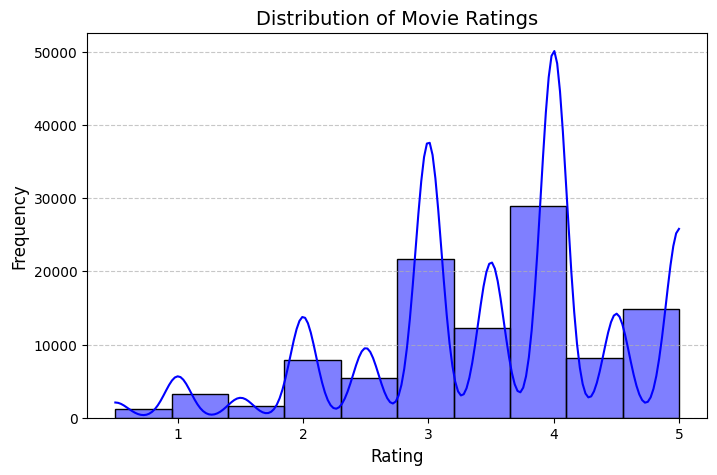

In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(data["rating"], bins=10, kde=True, color='blue')
plt.title("Distribution of Movie Ratings", fontsize=14)
plt.xlabel("Rating", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Description:
A histogram is plotted to visualize how ratings are distributed across the dataset. This helps in understanding user rating behavior and detecting biases or imbalances.

## Step 6: Create User-Item Matrix

In [6]:
user_movie_matrix = data.pivot(index='userId', columns='movieId', values='rating').fillna(0)
user_movie_sparse = csr_matrix(user_movie_matrix.values)

Description:
A pivot table is created to form a user-item matrix, where rows correspond to users and columns to movies. All missing values are replaced with zeros. The matrix is then converted into a sparse matrix for efficient computation.

## Step 7: Collaborative Filtering with SVD

In [7]:
U, sigma, Vt = svds(user_movie_sparse, k=50)
sigma = np.diag(sigma)
predicted_ratings = np.dot(np.dot(U, sigma), Vt)
predicted_df = pd.DataFrame(predicted_ratings, index=user_movie_matrix.index, columns=user_movie_matrix.columns)

Description:
Singular Value Decomposition (SVD) is applied to the sparse user-movie matrix. This technique decomposes the matrix into latent factors. The rating predictions are then reconstructed using the decomposed matrices.

## Step 8: Recommend Movies (Collaborative Filtering)

In [8]:
def recommend_movies_cf(user_id, num_recommendations=5):
    user_ratings = predicted_df.loc[user_id].sort_values(ascending=False)
    recommended_movie_ids = user_ratings.index[:num_recommendations]
    return movies[movies['movieId'].isin(recommended_movie_ids)]

# Example
recommend_movies_cf(1)

,movieId,title,genres
260,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
279,318,"Shawshank Redemption, The (1994)",Crime|Drama
525,593,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller
695,858,"Godfather, The (1972)",Crime|Drama
2056,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller


Description:
This function recommends top-rated movies to a given user by selecting items with the highest predicted ratings generated from the collaborative filtering model.

## Step 9: Train KNN Model for Content-Based Filtering

In [9]:
movie_features = user_movie_matrix.T
knn = NearestNeighbors(metric='cosine', algorithm='brute')
knn.fit(movie_features)

NearestNeighbors(algorithm='brute', metric='cosine')

Description:
To build a content-based recommender, the user-item matrix is transposed to create a movie-feature matrix. A K-Nearest Neighbors (KNN) model is trained on this matrix using cosine similarity to identify similar movies.

## Step 10: Recommend Movies (Content-Based)

In [10]:
def recommend_movies_cb(movie_id, num_recommendations=5):
    distances, indices = knn.kneighbors([movie_features.loc[movie_id]], n_neighbors=num_recommendations+1)
    recommended_movie_ids = movie_features.iloc[indices.flatten()[1:]].index
    return movies[movies['movieId'].isin(recommended_movie_ids)]

# Example
recommend_movies_cb(1)

,movieId,title,genres
230,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
646,780,Independence Day (a.k.a. ID4) (1996),Action|Adventure|Sci-Fi|Thriller
960,1198,Raiders of the Lost Ark (Indiana Jones and the...,Action|Adventure
971,1210,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Sci-Fi
1029,1270,Back to the Future (1985),Adventure|Comedy|Sci-Fi


Description:
This function takes a movie as input and returns a list of similar movies based on item-based KNN using cosine distance.

## Step 11: Hybrid Recommendation (CF + CB)

In [11]:
def recommend_movies_hybrid(user_id, movie_id, num_recommendations=5):
    cf_recommendations = recommend_movies_cf(user_id, num_recommendations//2)
    cb_recommendations = recommend_movies_cb(movie_id, num_recommendations//2)
    return pd.concat([cf_recommendations, cb_recommendations]).drop_duplicates()

# Example
recommend_movies_hybrid(1, 1)

,movieId,title,genres
260,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
279,318,"Shawshank Redemption, The (1994)",Crime|Drama
230,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
971,1210,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Sci-Fi


Description:
This function generates a hybrid recommendation by combining results from both collaborative and content-based methods. It aims to leverage the strengths of both approaches and reduce their individual weaknesses.

## Step 12: Evaluate Model with RMSE

In [12]:
train, test = train_test_split(data, test_size=0.2, random_state=42)
test_matrix = test.pivot(index='userId', columns='movieId', values='rating').fillna(0)
test_predicted = predicted_df.loc[test_matrix.index, test_matrix.columns]
rmse = np.sqrt(mean_squared_error(test_matrix.values.flatten(), test_predicted.values.flatten()))
print(f"\n{'='*40}\nModel Evaluation\n{'='*40}\nRMSE: {rmse:.4f}\n")


Model Evaluation
RMSE: 0.4483



Description:
The dataset is split into training and testing sets. Predictions are made for the test users and compared to actual ratings using Root Mean Squared Error (RMSE) — a standard measure of model accuracy.

# Conclusion
The notebook successfully demonstrates how to build and evaluate a movie recommender system using:

Collaborative Filtering with matrix factorization (SVD)

Content-Based Filtering with similarity-based KNN

A Hybrid method that merges the advantages of both approaches

The final model can provide personalized movie suggestions to users, either based on their own preferences, movie similarity, or a combination of both. This project lays the foundation for more advanced models involving implicit feedback, deep learning, or real-time systems.